# 02 - Baseline CNN from Scratch

In this notebook we build our first CNN model from scratch using Keras. We use `Conv2D`, `MaxPooling2D` and `Dense` layers
to solve a multi-label classification problem on chest X-ray images.

We focus on the 5 clinically most important conditions selected by Stanford
for the CheXpert competition (Irvin et al., 2019):
- Atelectasis
- Cardiomegaly
- Consolidation
- Edema
- Pleural Effusion

These were selected based on clinical importance and prevalence in the dataset,
and are used by all models on the [CheXpert leaderboard](https://stanfordmlgroup.github.io/competitions/chexpert/).

**Reference:** Irvin, J. et al. (2019). CheXpert: A Large Chest Radiograph Dataset
with Uncertainty Labels and Expert Comparison. *AAAI*. https://arxiv.org/abs/1901.07031

## 1. Import libraries
We use Keras (with TensorFlow as backend) to build the CNN model,
as covered in DAT255. Keras gives us access to layers such as `Conv2D`,
`MaxPooling2D` and `Dense` which are the core building blocks of
convolutional neural networks.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import tensorflow as tf
import keras
from keras import layers

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


## 2. Load data and define labels
We focus on the 5 clinically most important conditions from the CheXpert competition.
We also need to decide how to handle uncertain labels (-1).
The strategies described in the CheXpert paper are:
- U-Zeros: maps uncertain → 0 (negative)
- U-Ones: maps uncertain → 1 (positive)
- U-Ignore: ignores uncertain labels during training

We use U-Ones for Atelectasis and Edema, and U-Zeros for the rest,
following the Stanford baseline.

In [2]:
# Download dataset
path = kagglehub.dataset_download("ashery/chexpert")

# Load CSV files
train_df = pd.read_csv(os.path.join(path, "train.csv"))
valid_df = pd.read_csv(os.path.join(path, "valid.csv"))

# The 5 clinically most important conditions from the CheXpert competition
LABELS = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']

# Handle uncertain labels (-1)
# U-Ones for Atelectasis and Edema, U-Zeros for the rest (Irvin et al., 2019)
u_ones = ['Atelectasis', 'Edema']
u_zeros = ['Cardiomegaly', 'Consolidation', 'Pleural Effusion']

for col in u_ones:
    train_df[col] = train_df[col].replace(-1, 1)

for col in u_zeros:
    train_df[col] = train_df[col].replace(-1, 0)

# Fill remaining NaN with 0
train_df[LABELS] = train_df[LABELS].fillna(0)
valid_df[LABELS] = valid_df[LABELS].fillna(0)

# Use only frontal images
train_df = train_df[train_df['Frontal/Lateral'] == 'Frontal']
valid_df = valid_df[valid_df['Frontal/Lateral'] == 'Frontal']

print(f"Training images: {len(train_df)}")
print(f"Validation images: {len(valid_df)}")

Training images: 191027
Validation images: 202


## 3. Data pipeline with tf.data

We use `tf.data` for efficient data handling. Images are resized to
224x224 pixels and normalized to values between 0 and 1.
We use only frontal images since lateral images have a different angle
and may confuse the model.

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(img_path, labels):
    # Read and preprocess image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0, 1]
    return img, labels

def make_dataset(df, shuffle=True):
    # Fix image paths
    paths = df['Path'].str.replace('CheXpert-v1.0-small/', '', regex=False)
    paths = [os.path.join(path, p) for p in paths]
    labels = df[LABELS].values.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = make_dataset(train_df, shuffle=True)
valid_ds = make_dataset(valid_df, shuffle=False)

print("Data pipeline ready!")

Data pipeline ready!


## 4. Build CNN model from scratch

We build a simple CNN with the following architecture, inspired by Chapter 8
in Chollet (2025) *Deep Learning with Python*:

- Conv2D + MaxPooling2D blocks to extract image features
- Dropout for regularization and to prevent overfitting
- Dense layers for classification
- Sigmoid activation in the output since this is multi-label
  (not multi-class) classification, each image can have multiple conditions simultaneously

In [4]:
def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=5):
    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # Output — sigmoid for multi-label classification
    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    return model

model = build_baseline_cnn()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,493 (1.74 MB)

 Trainable params: 455,493 (1.74 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile the model

We use the Adam optimizer as covered in the course, and
Binary Crossentropy as the loss function since this is multi-label
classification. AUC (Area Under the ROC Curve) is the standard evaluation
metric for CheXpert and is used on the leaderboard.

In [5]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.AUC(name='auc', multi_label=True),
        keras.metrics.BinaryAccuracy(name='accuracy')
    ]
)

print("Model compiled!")

Model compiled!


## 6. Train the model

We use the following callbacks during training:
- EarlyStopping - stops training if validation performance stops improving
- ModelCheckpoint - saves the best model during training
- ReduceLROnPlateau - reduces the learning rate if the model stops improving

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=5,
        mode='max',
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='../results/baseline_cnn_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=3,
        mode='max',
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 1809s 303ms/step - accuracy: 0.7599 - auc: 0.5914 - loss: 0.4966 - val_accuracy: 0.7337 - val_auc: 0.7483 - val_loss: 0.5713 - learning_rate: 1.0000e-04
Epoch 2/20
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 1676s 281ms/step - accuracy: 0.7700 - auc: 0.6364 - loss: 0.4799 - val_accuracy: 0.7386 - val_auc: 0.7663 - val_loss: 0.5698 - learning_rate: 1.0000e-04
Epoch 3/20
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 1461s 245ms/step - accuracy: 0.7777 - auc: 0.6552 - loss: 0.4706 - val_accuracy: 0.7465 - val_auc: 0.7725 - val_loss: 0.5692 - learning_rate: 1.0000e-04
Epoch 4/20
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 1443s 242ms/step - accuracy: 0.7819 - auc: 0.6665 - loss: 0.4645 - val_accuracy: 0.7475 - val_auc: 0.7941 - val_loss: 0.5635 - learning_rate: 1.0000e-04
Epoch 5/20
5970/5970 ━━━━━━━━━━━━━━━━━━━━ 2033s 341ms/step - accuracy: 0.7855 - auc: 0.6779 - loss: 0.4588 - val_accuracy: 0.7535 - val_auc: 0.8159 - val_loss: 0.5410 - learning_rate: 1.0000e-04
Epoch 6/20
5970/5970 ━━━━

## 7. Visualize training history

We plot AUC and loss for training and validation to assess whether
the model is overfitting or underfitting.

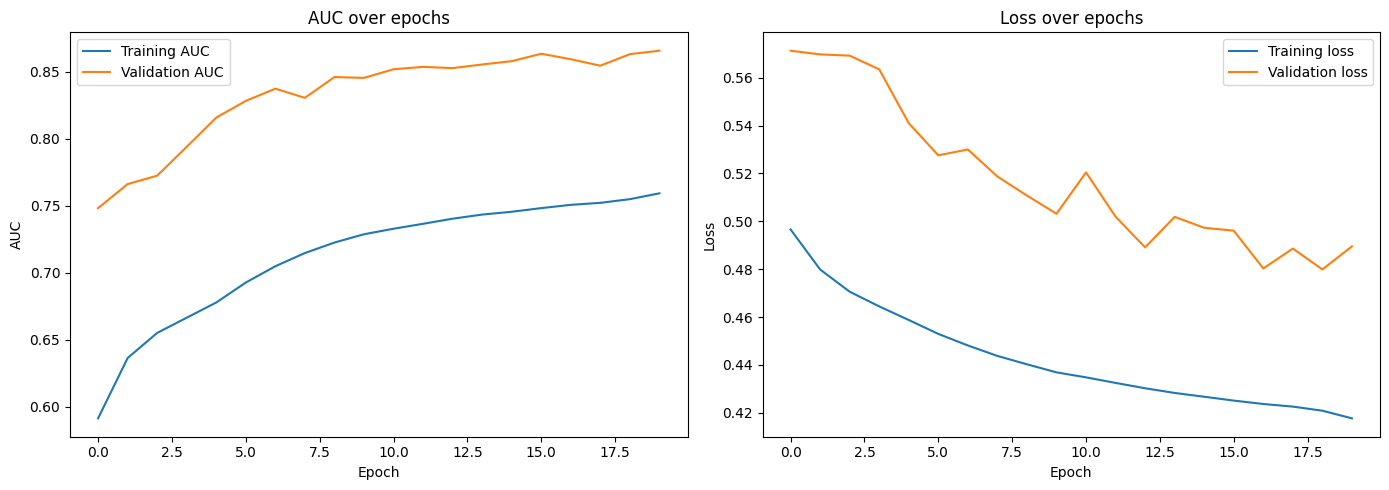

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC
axes[0].plot(history.history['auc'], label='Training AUC')
axes[0].plot(history.history['val_auc'], label='Validation AUC')
axes[0].set_title('AUC over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUC')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Training loss')
axes[1].plot(history.history['val_loss'], label='Validation loss')
axes[1].set_title('Loss over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/figures/baseline_cnn_training.png')
plt.show()

## 8. Evaluate the model

We evaluate the model on the validation set and compute AUC per condition
to see which conditions the model handles best.
We compare against the Stanford baseline AUC of 0.907 (Irvin et al., 2019).

In [8]:
from sklearn.metrics import roc_auc_score

# Get predictions
y_pred = model.predict(valid_ds)
y_true = np.concatenate([y for _, y in valid_ds], axis=0)

# AUC per condition
print("=== AUC per condition ===")
for i, label in enumerate(LABELS):
    auc = roc_auc_score(y_true[:, i], y_pred[:, i])
    print(f"{label}: {auc:.4f}")

# Mean AUC
mean_auc = roc_auc_score(y_true, y_pred, average='macro')
print(f"\nMean AUC: {mean_auc:.4f}")
print(f"Stanford baseline AUC: 0.907 (Irvin et al., 2019)")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
=== AUC per condition ===
Atelectasis: 0.8230
Cardiomegaly: 0.8031
Consolidation: 0.8947
Edema: 0.9223
Pleural Effusion: 0.8833

Mean AUC: 0.8653
Stanford baseline AUC: 0.907 (Irvin et al., 2019)
